# PhonePay Case Study

**This case study involves analyzing transaction data from the financial application PhonePe along with demographic data across various states and districts in India. The objective is to provide insights into transaction trends, device usage, and demographic correlations, while ensuring data consistency and performing advanced analyses to uncover deeper insights.**

# Data Dictionary

1. **State_Txn and Users**
**State**: Name of the state
Year: Year of the data
Quarter: Quarter of the year
Transactions: Number of transactions
Amount (INR): Total amount of transactions in INR
ATV (INR): Average transaction value in INR
Registered Users: Number of registered users
App Opens: Number of app opens


2. **State_TxnSplit
State**: Name of the state
Year: Year of the data
Quarter: Quarter of the year
Transaction Type: Type of transaction (e.g., Recharge & bill payments, Peer-to-peer payments)
Transactions: Number of transactions
Amount (INR): Total amount of transactions in INR
ATV (INR): Average transaction value in INR


3. **State_DeviceData
State**: Name of the state
Year: Year of the data
Quarter: Quarter of the year
Brand: Brand of the device
Registered Users: Number of registered users using the brand
Percentage: Percentage of registered users using the brand


4. **District_Txn and Users
State**: Name of the state
Year: Year of the data
Quarter: Quarter of the year
District: Name of the district
Code: District code
Transactions: Number of transactions
Amount (INR): Total amount of transactions in INR
ATV (INR): Average transaction value in INR
Registered Users: Number of registered users
App Opens: Number of app opens


5. **District Demographics
State**: Name of the state
District: Name of the district
Headquarters: District headquarters
Population: Population of the district
Area (sq km): Area of the district in square kilometers
Density: Population density
Code: District code
Alternate Name: Alternate name of the district

# Importing Important Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connecting Google Drive with Collab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 1: Data Loading and Understanding

1.1: Load each dataset and display its structure
1. Load the State_Txn and Users dataset and display its first 5 rows.
2. Load the State_TxnSplit dataset and display its bottom 10 rows.
3. Load the State_DeviceData dataset and display 10 rows from the middle of the dataset.
4. Load the District_Txn and Users dataset and display its first 10 rows and last 10 rows.
5. Load the District Demographics dataset and display every 10th row.



In [3]:
df_Statetxn = pd.read_excel("/content/drive/MyDrive/DataSets/phonepe_pulse.xlsx",sheet_name="State_Txn and Users")

In [6]:
df_Statetxn.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [4]:
df_Statetxnsplit = pd.read_excel("/content/drive/MyDrive/DataSets/phonepe_pulse.xlsx",sheet_name="State_TxnSplit")

In [8]:
df_Statetxnsplit.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


In [5]:
df_Devicedata = pd.read_excel("/content/drive/MyDrive/DataSets/phonepe_pulse.xlsx",sheet_name="State_DeviceData")

In [10]:
mid = len(df_Devicedata) // 2
df_Devicedata.iloc[mid-5:mid+5]

,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


In [6]:
# District_Txn and Users
df_district = pd.read_excel("/content/drive/MyDrive/DataSets/phonepe_pulse.xlsx",sheet_name="District_Txn and Users")

In [38]:
df_district.head(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


In [39]:
df_district.tail(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


In [7]:
df_Demographics = pd.read_excel("/content/drive/MyDrive/DataSets/phonepe_pulse.xlsx",sheet_name="District Demographics")

In [12]:
df_Demographics.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North



# 1.2: Display basic statistics and data types for each dataset

1. For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns.
2. Display the data types of each column in each dataset.

In [14]:
df_Statetxn.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


In [15]:
df_Statetxnsplit.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


In [16]:
df_Devicedata.describe()

,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


In [40]:
df_district.describe()

,Year,Quarter,Transactions,Amount (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,1.060461e+07,5.544197e+08


In [17]:
df_Demographics.describe()

,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


In [18]:
df_Statetxn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    object 
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      504 non-null    int64  
 4   Amount (INR)      503 non-null    float64
 5   ATV (INR)         504 non-null    float64
 6   Registered Users  504 non-null    int64  
 7   App Opens         504 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 31.6+ KB


In [19]:
df_Statetxnsplit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             2514 non-null   object 
 1   Year              2514 non-null   int64  
 2   Quarter           2514 non-null   int64  
 3   Transaction Type  2514 non-null   object 
 4   Transactions      2514 non-null   int64  
 5   Amount (INR)      2514 non-null   float64
 6   ATV (INR)         2514 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 137.6+ KB


In [20]:
df_Devicedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             5544 non-null   object 
 1   Year              5544 non-null   int64  
 2   Quarter           5544 non-null   int64  
 3   Brand             5544 non-null   object 
 4   Registered Users  5544 non-null   int64  
 5   Percentage        5544 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 260.0+ KB


In [41]:
df_district.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10248 entries, 0 to 10247
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             10248 non-null  object 
 1   Year              10248 non-null  int64  
 2   Quarter           10248 non-null  int64  
 3   District          10248 non-null  object 
 4   Code              10220 non-null  object 
 5   Transactions      10248 non-null  int64  
 6   Amount (INR)      10248 non-null  float64
 7   ATV (INR)         10248 non-null  object 
 8   Registered Users  10248 non-null  int64  
 9   App Opens         10248 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 800.8+ KB


In [21]:
df_Demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           742 non-null    object 
 1   District        742 non-null    object 
 2   Headquarters    742 non-null    object 
 3   Population      742 non-null    int64  
 4   Area (sq km)    742 non-null    float64
 5   Density         742 non-null    int64  
 6   Code            742 non-null    object 
 7   Alternate Name  742 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 46.5+ KB


# 1.3: Check for missing values

1. Identify any missing values in each dataset.
2. Calculate the percentage of missing values for each column that has missing values.
3. Highlight which column has the highest percentage of missing values in each dataset.

In [23]:
df_Statetxn.isna().sum()

# There is only one missing value in State_Txn DataSet in Amount(INR) Column

,0
State,0
Year,0
Quarter,0
Transactions,0
Amount (INR),1
ATV (INR),0
Registered Users,0
App Opens,0


In [32]:

missing_percent = (df_Statetxn.isnull().mean() * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("Only Amount (INR) has missing values in the dataset")
print(missing_percent)



Only Amount (INR) has missing values in the dataset
Amount (INR)    0.198413
dtype: float64


In [25]:
df_Statetxnsplit.isna().sum()

# There is no missing values in State_Txn_Split DataSet

,0
State,0
Year,0
Quarter,0
Transaction Type,0
Transactions,0
Amount (INR),0
ATV (INR),0


In [26]:
df_Devicedata.isna().sum()

# There is no missing Values in Device_Data Dataset

,0
State,0
Year,0
Quarter,0
Brand,0
Registered Users,0
Percentage,0


In [45]:
df_district.isna().sum()

,0
State,0
Year,0
Quarter,0
District,0
Code,28
Transactions,0
Amount (INR),0
ATV (INR),0
Registered Users,0
App Opens,0


In [50]:
missing_percent = (df_district.isnull().mean() * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(f"Total Missing values in column {missing_percent}")

Total Missing values in column Code    0.273224
dtype: float64


In [27]:
df_Demographics.isna().sum()

# There is no missing values in Demographics Dataset

,0
State,0
District,0
Headquarters,0
Population,0
Area (sq km),0
Density,0
Code,0
Alternate Name,0


# 1.4: Create a summary

1. Calculate the total number of states and the total number of districts.
2. Identify the state with the highest number of districts. [hint: you can use value_counts() and idxmax()]

In [54]:
print(f"Total number of States : {df_Statetxn['State'].nunique()}")
print(f"Total number of Districts : {df_district['District'].nunique()}")

Total number of States : 36
Total number of Districts : 723


In [61]:
counts = df_district.groupby('State')['District'].nunique()

state_max = counts.idxmax()
max_districts = int(counts.max())

print(f"{state_max} has the highest number of districts: {max_districts}")

Uttar Pradesh has the highest number of districts: 75


# Task 2: Exploratory Data Analysis (EDA)

2.1: Analyze transaction trends over the years for each state
1. Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.
2. Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.

In [62]:
df_Statetxn.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [63]:
result = df_Statetxn.groupby(['State', 'Year']).agg({
    'Transactions': 'sum',
    'Amount (INR)': 'sum'
}).reset_index()

print(result)

                         State  Year  Transactions  Amount (INR)
0    Andaman & Nicobar Islands  2018         58021  1.890761e+08
1    Andaman & Nicobar Islands  2019        133104  4.734648e+08
2    Andaman & Nicobar Islands  2020        446274  1.296423e+09
3    Andaman & Nicobar Islands  2021        586166  1.682854e+09
4               Andhra Pradesh  2018      77779112  1.220720e+11
..                         ...   ...           ...           ...
139                Uttarakhand  2021      44608834  7.727901e+10
140                West Bengal  2018     120011635  1.115887e+11
141                West Bengal  2019     257900590  2.660145e+11
142                West Bengal  2020     304222327  5.527316e+11
143                West Bengal  2021     260151489  5.223720e+11

[144 rows x 4 columns]


In [64]:
state_txn = df_Statetxn.groupby('State')['Transactions'].sum()

top_5 = state_txn.nlargest(5)
bottom_5 = state_txn.nsmallest(5)

print("Top 5 States (Highest Transactions):")
print(top_5)

print("\nTop 5 States (Lowest Transactions):")
print(bottom_5)

Top 5 States (Highest Transactions):
State
Karnataka         2981044533
Maharashtra       2833670154
Telangana         2347430243
Andhra Pradesh    1781091169
Rajasthan         1382918930
Name: Transactions, dtype: int64

Top 5 States (Lowest Transactions):
State
Lakshadweep                    71610
Andaman & Nicobar Islands    1223565
Ladakh                       1880109
Mizoram                      2162776
Meghalaya                    5648913
Name: Transactions, dtype: int64


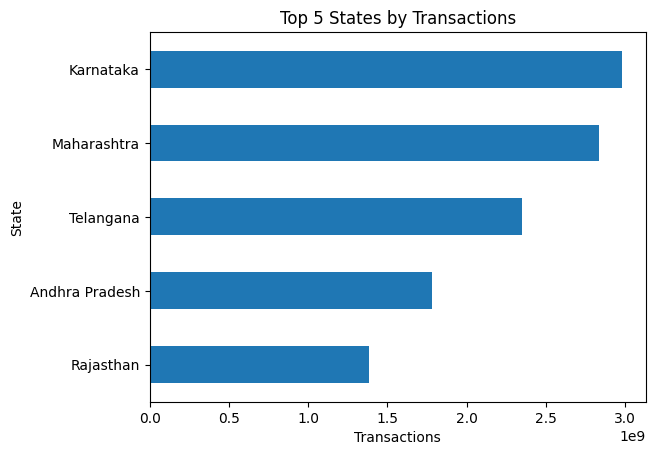

In [66]:

# Plot
plt.figure()

top_5.sort_values().plot(kind='barh', title="Top 5 States by Transactions")
plt.xlabel("Transactions")
plt.show()



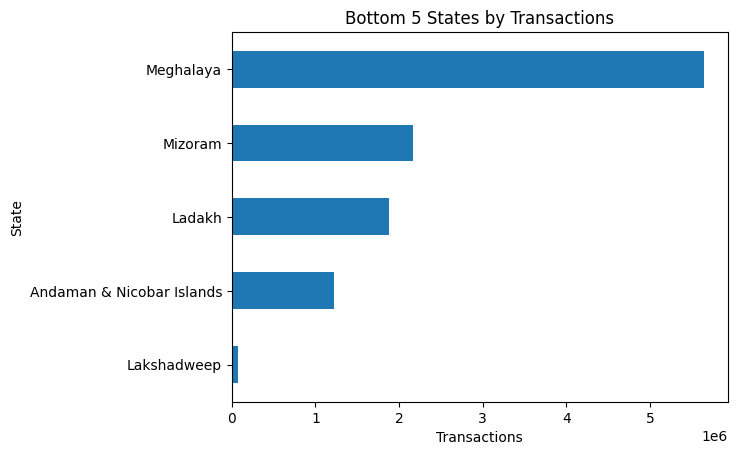

In [67]:
plt.figure()

bottom_5.sort_values().plot(kind='barh', title="Bottom 5 States by Transactions")
plt.xlabel("Transactions")
plt.show()

# 2.2: Identify the most common transaction types in each state and quarter

1. For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.

In [69]:
df_Statetxnsplit.head()

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6487.790112
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,1518.480432
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,321.255149
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05,721.444790


In [94]:
# 1. Group by the three main categories and use .size()
# .size() counts the number of rows for each unique combination
freq_df = df_Statetxnsplit.groupby(['State', 'Quarter', 'Transaction Type']).size().reset_index(name='Frequency')

# 2. Sort the data so the highest frequency is at the top
freq_df = freq_df.sort_values(by=['State', 'Quarter', 'Frequency'], ascending=[True, True, False])

# 3. Pick the 'Winner' for each State and Quarter
# idxmax() finds the index of the row with the highest 'Frequency' for each group
most_common_tx = freq_df.loc[freq_df.groupby(['State', 'Quarter'])['Frequency'].idxmax()]

# 4. Display the results
print(most_common_tx[['State', 'Quarter', 'Transaction Type', 'Frequency']])

                         State  Quarter    Transaction Type  Frequency
0    Andaman & Nicobar Islands        1  Financial Services          4
5    Andaman & Nicobar Islands        2  Financial Services          4
10   Andaman & Nicobar Islands        3  Financial Services          3
15   Andaman & Nicobar Islands        4  Financial Services          3
20              Andhra Pradesh        1  Financial Services          4
..                         ...      ...                 ...        ...
695                Uttarakhand        4  Financial Services          3
700                West Bengal        1  Financial Services          4
705                West Bengal        2  Financial Services          4
710                West Bengal        3  Financial Services          3
715                West Bengal        4  Financial Services          3

[144 rows x 4 columns]


# 2.3: Determine the device brand with the highest number of registered users in each state
1. Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format.#

In [95]:
df_Devicedata.head()

,State,Year,Quarter,Brand,Registered Users,Percentage
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258


In [100]:
result = df_Devicedata.groupby('Brand').sum()['Registered Users']
result.sort_values(ascending=False)

,Registered Users
Brand,
Xiaomi,615566524
Samsung,480799591
Vivo,411369522
Oppo,283522909
Others,211221642
Realme,134416015
Apple,67132534
Motorola,57086814
OnePlus,44184950


# 2.4: Create a list of the top district per state based on population
1. For each state, identify the district with the highest population. Display the results in a tabular format.
2. Create a column chart depicting the district with the highest population for each state.

In [101]:
df_district.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


In [111]:
result = df_district.groupby(['State','District'])['Registered Users'].sum().reset_index()

In [112]:
top_districts = result.loc[
    result.groupby('State')['Registered Users'].idxmax()
]

print(top_districts)

                                    State                    District  \
2               Andaman & Nicobar Islands               South Andaman   
12                         Andhra Pradesh               Visakhapatnam   
32                      Arunachal Pradesh                  Papum Pare   
59                                  Assam         Kamrup Metropolitan   
99                                  Bihar                       Patna   
112                            Chandigarh                  Chandigarh   
135                          Chhattisgarh                      Raipur   
140  Dadra & Nagar Haveli and Daman & Diu      Dadra And Nagar Haveli   
153                                 Delhi                        West   
154                                   Goa                   North Goa   
156                               Gujarat                   Ahmadabad   
194                               Haryana                    Gurugram   
221                      Himachal Pradesh          

In [114]:
top_districts = top_districts.sort_values('State')
top_districts

,State,District,Registered Users
2,Andaman & Nicobar Islands,South Andaman,345694
12,Andhra Pradesh,Visakhapatnam,21285794
32,Arunachal Pradesh,Papum Pare,633358
59,Assam,Kamrup Metropolitan,4994310
99,Bihar,Patna,17187297
112,Chandigarh,Chandigarh,3801466
135,Chhattisgarh,Raipur,6815202
140,Dadra & Nagar Haveli and Daman & Diu,Dadra And Nagar Haveli,1614726
153,Delhi,West,14172440
154,Goa,North Goa,2950631


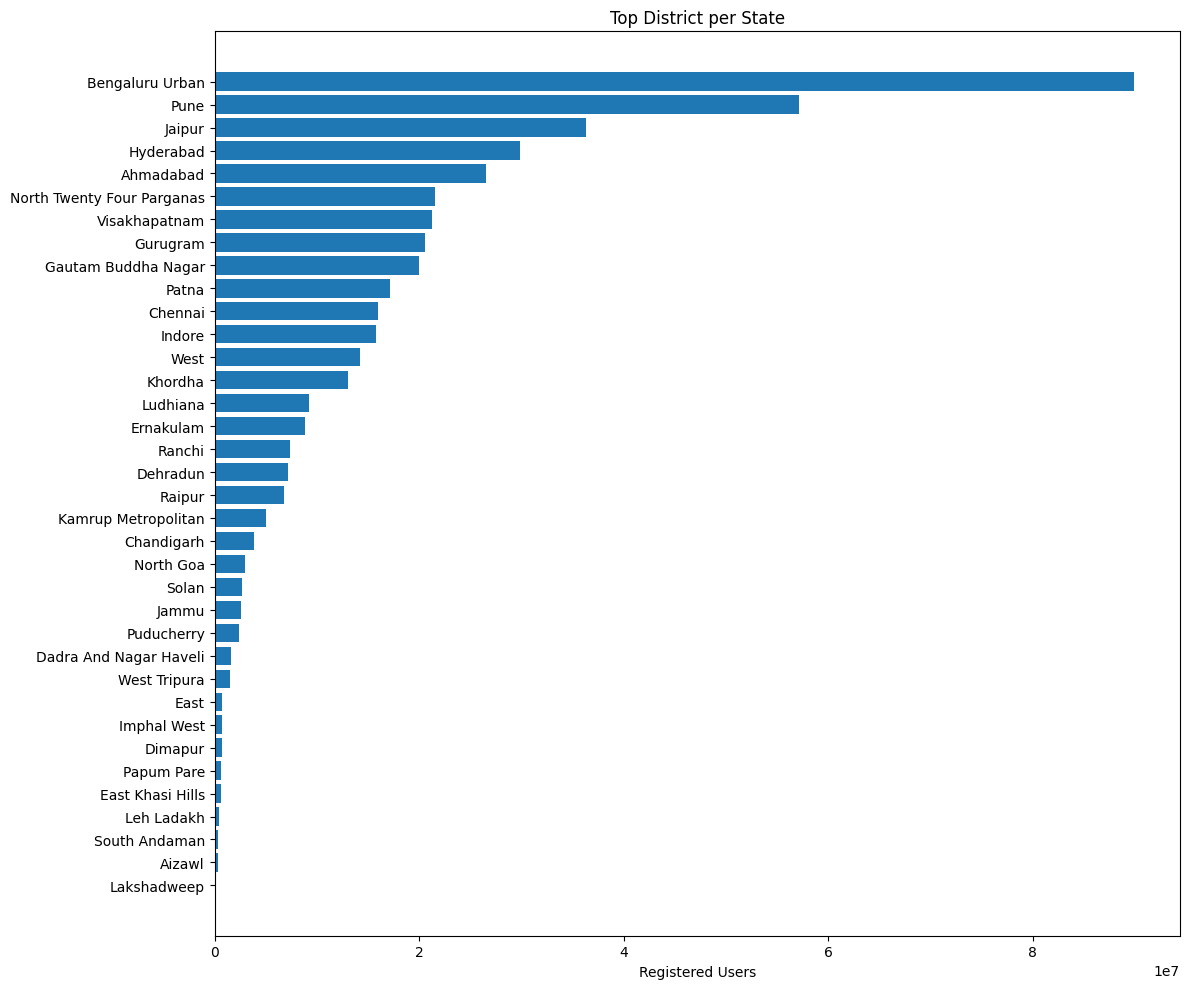

In [116]:
plt.figure(figsize=(12, 10))

top_districts_sorted = top_districts.sort_values('Registered Users')

plt.barh(top_districts_sorted['District'], top_districts_sorted['Registered Users'])

plt.title("Top District per State")
plt.xlabel("Registered Users")

plt.tight_layout()
plt.show()


# 2.5: Calculate the average transaction value (ATV) for each state

1. Compute the average transaction value for each state. Display the results in a tabular format.
2. Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.

In [117]:
df_Statetxn.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [121]:
result = df_Statetxn.groupby('State').agg({
    'Transactions': 'sum',
    'Amount (INR)': 'sum'
}).reset_index()

result['Avg_Transaction_Value'] = result['Amount (INR)'] / result['Transactions']

print(result[['State', 'Avg_Transaction_Value']])

                                   State  Avg_Transaction_Value
0              Andaman & Nicobar Islands            2976.399178
1                         Andhra Pradesh            1789.828350
2                      Arunachal Pradesh            2766.333539
3                                  Assam            2277.175192
4                                  Bihar            2297.474906
5                             Chandigarh            2104.990740
6                           Chhattisgarh            1718.150602
7   Dadra & Nagar Haveli and Daman & Diu            1497.232192
8                                  Delhi            1631.940078
9                                    Goa            1808.372977
10                               Gujarat            1803.167412
11                               Haryana            1866.717628
12                      Himachal Pradesh            1846.955544
13                       Jammu & Kashmir            2430.351780
14                             Jharkhand

In [128]:
# top 5 States with Highest ATV
df_Statetxn[['State', 'ATV (INR)']].sort_values(by='ATV (INR)',ascending=False).head()

,State,ATV (INR)
189,Jammu & Kashmir,3938.733850
8,Andaman & Nicobar Islands,3910.027418
7,Andaman & Nicobar Islands,3891.991539
241,Ladakh,3848.877978
245,Ladakh,3833.132954


In [129]:
# Botton 5 States with Lowest ATV
df_Statetxn[['State', 'ATV (INR)']].sort_values(by='ATV (INR)').head()

,State,ATV (INR)
26,Andhra Pradesh,0.000000
352,Odisha,768.481188
492,West Bengal,779.138070
350,Odisha,796.518896
490,West Bengal,907.410281


# 2.6: Analyze app usage trends
1. Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.
2. Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

In [132]:
df_Statetxn.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [133]:
result = df_Statetxn.groupby('State')['App Opens'].sum().sort_values(ascending=False).reset_index()
result

,State,App Opens
0,Maharashtra,6145385557
1,Karnataka,6010582453
2,Andhra Pradesh,5352179585
3,Telangana,4737814072
4,Rajasthan,3914112235
5,Uttar Pradesh,3744913382
6,Madhya Pradesh,2937727396
7,Bihar,2043130469
8,West Bengal,2006508265
9,Odisha,1829219041


In [134]:
state_data = df_Statetxn[df_Statetxn['State'] == 'Uttar Pradesh']

In [135]:
state_data = state_data.sort_values(['Year', 'Quarter'])

In [136]:
state_data['Time'] = state_data['Year'].astype(str) + '-Q' + state_data['Quarter'].astype(str)

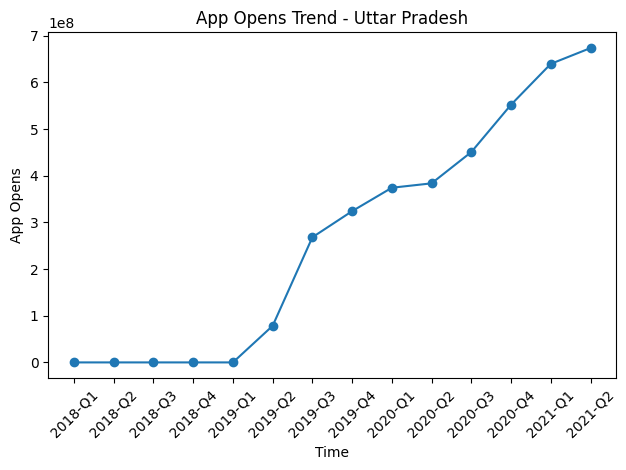

In [137]:
plt.figure()

plt.plot(state_data['Time'], state_data['App Opens'], marker='o')

plt.title("App Opens Trend - Uttar Pradesh")
plt.xlabel("Time")
plt.ylabel("App Opens")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2.7: Distribution of transaction types

1. Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

In [9]:
df_Statetxnsplit.head()

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6487.790112
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,1518.480432
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,321.255149
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05,721.444790


In [17]:
latest = df_Statetxnsplit.loc[
    df_Statetxnsplit.groupby(['State','Year'])['Quarter'].idxmax()
]

In [18]:
latest_year = latest['Year'].max()
latest = latest[latest['Year'] == latest_year]

In [19]:
pivot = latest.pivot_table(
    index='State',
    columns='Transaction Type',
    values='Transactions',
    aggfunc='sum',
    fill_value=0
)

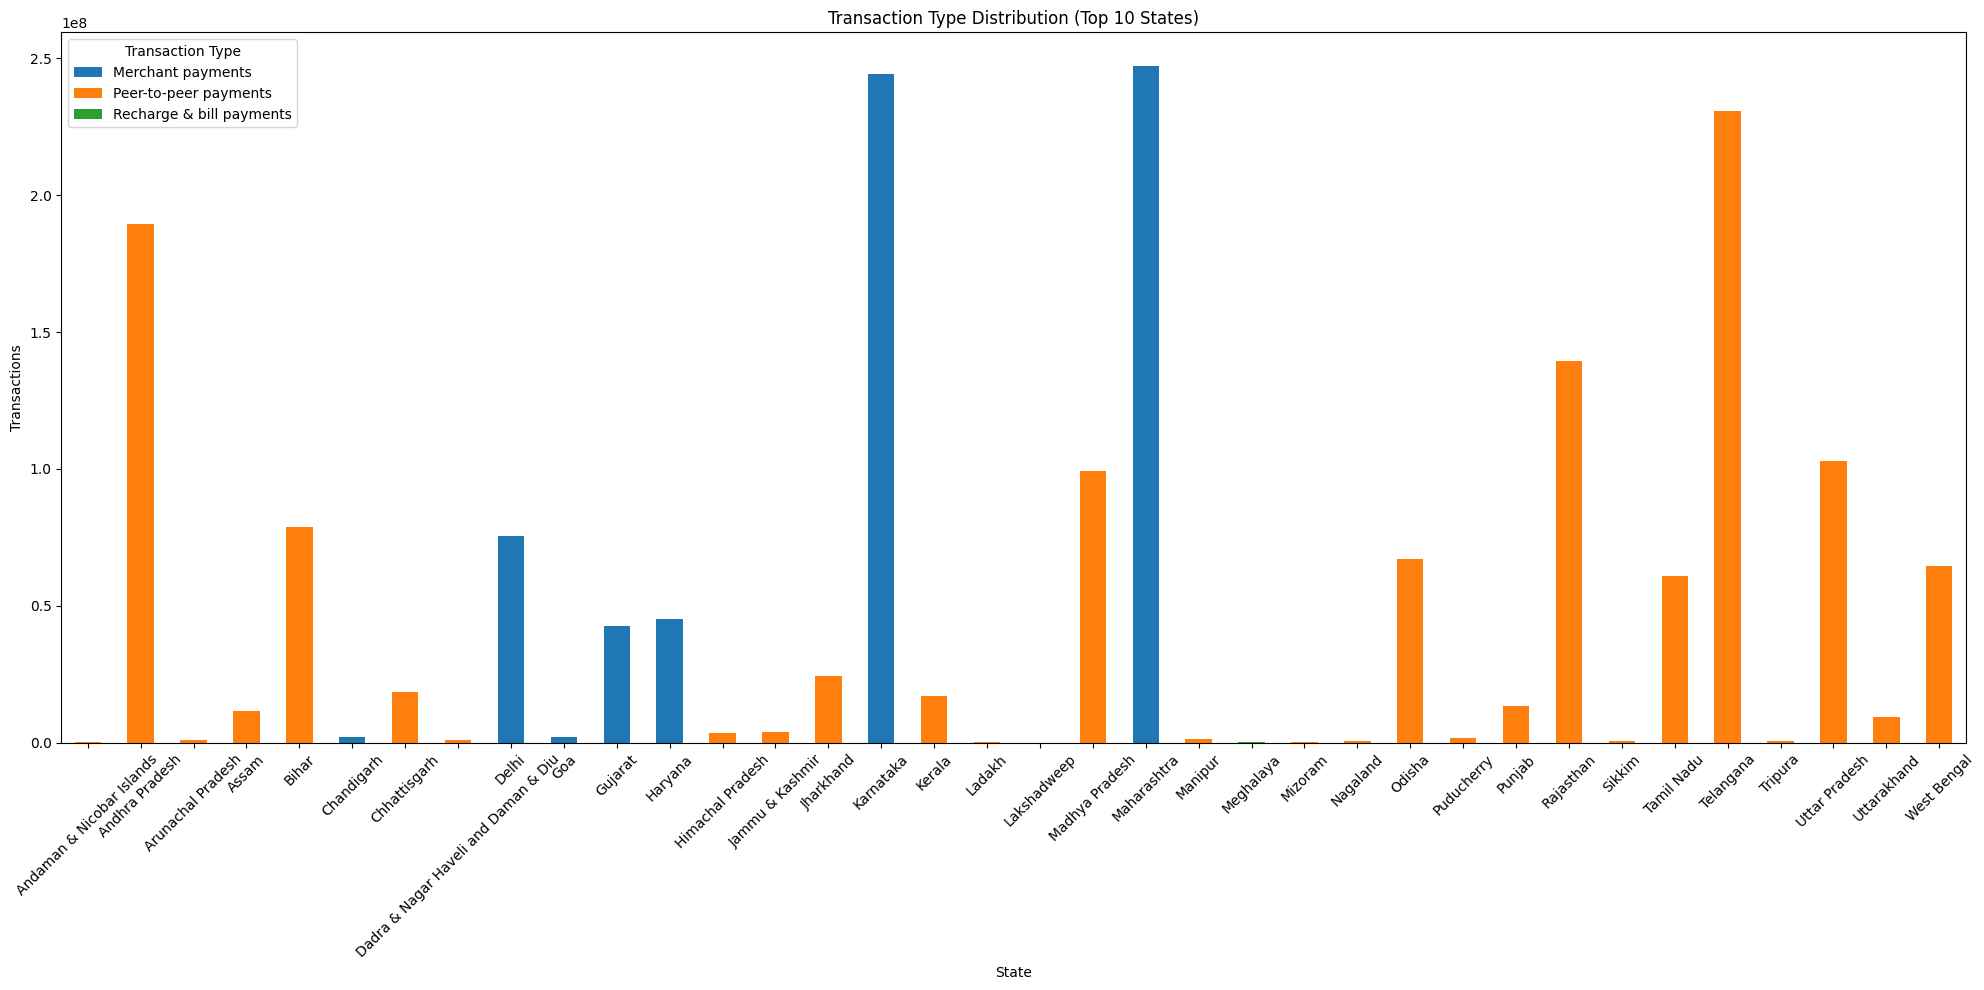

In [28]:
pivot.plot(kind='bar', stacked=True, figsize=(20,10))

plt.title("Transaction Type Distribution (Top 10 States)")
plt.xlabel("State")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2.8: Find unique mapping between district name and district code

1. Identify the unique mapping between district names and district codes from the dataset. [hint: you can use drop_duplicates()]
2. Create a CSV file containing the unique district name and district code mappings.
3. Export the CSV file.

In [34]:
result = df_district[['District','Code']].drop_duplicates()
result.count()

,0
District,732
Code,730


In [36]:
result.to_csv('district_postal.csv', index=False)

In [38]:

result.to_csv('/content/drive/MyDrive/DataSets/district_postal.csv', index=False)

# Task 3: Data Quality Checks
3.1: Ensure data consistency across state and district levels
1. For each state, calculate the total number of transactions, total transaction amount, and total registered users by summing up the values from the district level data.
2. Compare the results with the corresponding values at the state level to ensure they match.
3. Display any discrepancies found between the district-level and state-level data

In [40]:
df_district.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


In [63]:
district_summary = df_district.groupby('State').agg(
    District_Transactions=('Transactions', 'sum'),
    Transaction_Count=('Transactions', 'count'),
    District_Users=('Registered Users', 'sum')
)

In [64]:
district_summary

,District_Transactions,Transaction_Count,District_Users
State,,,
Andaman & Nicobar Islands,1223565,42,408396
Andhra Pradesh,1781091169,182,158007957
Arunachal Pradesh,8043799,350,1862214
Assam,123577981,462,26860751
Bihar,713643889,532,115284760
Chandigarh,25516542,14,3801466
Chhattisgarh,241908549,378,37448388
Dadra & Nagar Haveli and Daman & Diu,12462185,42,2701112
Delhi,1011031124,154,95374654


In [52]:
state_summary = df_Statetxn.groupby('State', as_index=False).agg(
    State_Transactions=('Transactions', 'sum'),
    State_Users=('Registered Users', 'sum')
)

In [53]:
state_summary

,State,State_Transactions,State_Users
0,Andaman & Nicobar Islands,1223565,408396
1,Andhra Pradesh,1781091169,158007957
2,Arunachal Pradesh,8043799,1862214
3,Assam,123577981,26860751
4,Bihar,713643889,115284760
5,Chandigarh,25516542,3801466
6,Chhattisgarh,241908549,37448388
7,Dadra & Nagar Haveli and Daman & Diu,12462185,2701112
8,Delhi,1011031124,95374654
9,Goa,24481604,4755320


In [65]:
comparison = district_summary.merge(state_summary, on='State')

In [66]:
comparison['Transaction_Match'] = (
    comparison['District_Transactions'] == comparison['State_Transactions']
)

comparison['User_Match'] = (
    comparison['District_Users'] == comparison['State_Users']
)

print(comparison)

                                   State  District_Transactions  \
0              Andaman & Nicobar Islands                1223565   
1                         Andhra Pradesh             1781091169   
2                      Arunachal Pradesh                8043799   
3                                  Assam              123577981   
4                                  Bihar              713643889   
5                             Chandigarh               25516542   
6                           Chhattisgarh              241908549   
7   Dadra & Nagar Haveli and Daman & Diu               12462185   
8                                  Delhi             1011031124   
9                                    Goa               24481604   
10                               Gujarat              612992823   
11                               Haryana              567751410   
12                      Himachal Pradesh               52987445   
13                       Jammu & Kashmir               4505332

In [67]:
discrepancies = comparison[
    (comparison['District_Transactions'] != comparison['State_Transactions']) |
    (comparison['District_Users'] != comparison['State_Users'])
]

print(discrepancies)

Empty DataFrame
Columns: [State, District_Transactions, Transaction_Count, District_Users, State_Transactions, State_Users, Transaction_Match, User_Match]
Index: []


In [69]:
if discrepancies.empty:
    print("No discrepancies found ")
else:
    print(discrepancies)

No discrepancies found 


# Task 4: Data Merging and Advanced Analysis
4.1: Ratio of users to population by state
1. Merge the State_Txn and Users dataset with the District Demographics dataset to calculate the ratio of registered users to the population for each state. Display the results in a tabular format.
2. Create a column chart depicting the ratio of users to population by state.

In [72]:
# State Users
users_state = df_Statetxn.groupby('State', as_index=False)['Registered Users'].sum()

# State Population
pop_state = df_Demographics.groupby('State', as_index=False)['Population'].sum()

# Merge
merged = users_state.merge(pop_state, on='State')

# Ratio
merged['User_Pop_Ratio'] = merged['Registered Users'] / merged['Population']

print(merged)

                                   State  Registered Users  Population  \
0              Andaman & Nicobar Islands            408396      380581   
1                         Andhra Pradesh         158007957    49378776   
2                      Arunachal Pradesh           1862214     1606047   
3                                  Assam          26860751    34461385   
4                                  Bihar         115284760   103817951   
5                             Chandigarh           3801466     1055450   
6                           Chhattisgarh          37448388    25867958   
7   Dadra & Nagar Haveli and Daman & Diu           2701112      586956   
8                                  Delhi          95374654    16787941   
9                                    Goa           4755320     1457723   
10                               Gujarat         126380032    65930328   
11                               Haryana          85564119    25855357   
12                      Himachal Prade

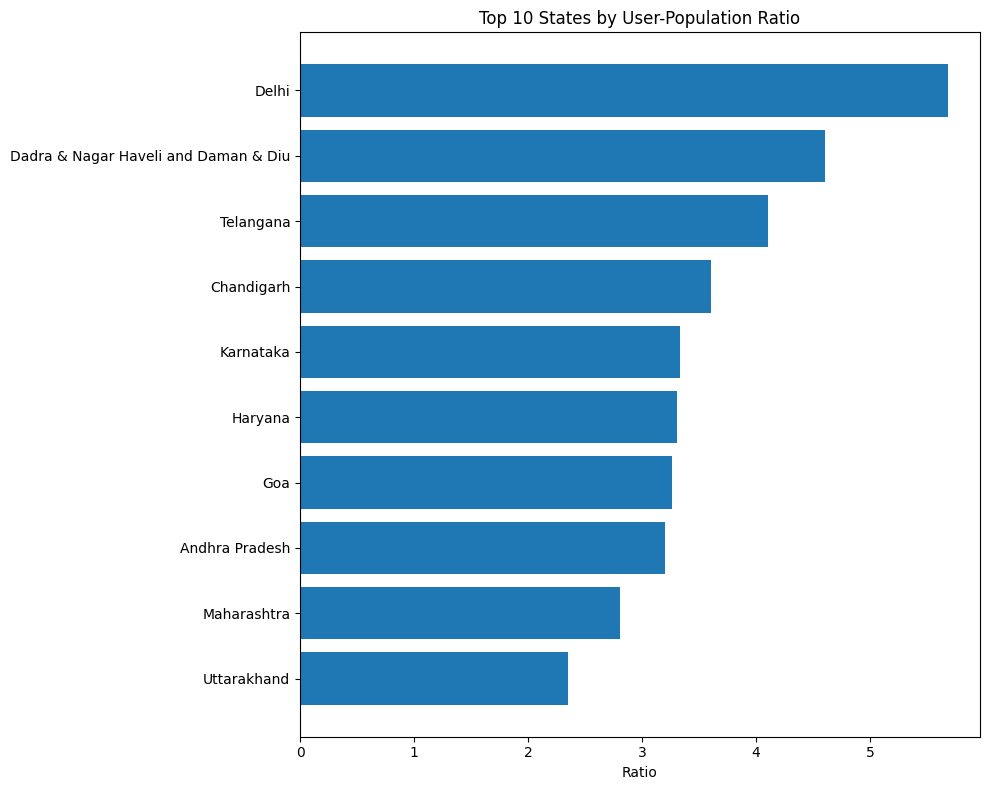

In [73]:
top10 = merged.sort_values('User_Pop_Ratio', ascending=True).tail(10)

plt.figure(figsize=(10,8))

plt.barh(top10['State'], top10['User_Pop_Ratio'])

plt.title("Top 10 States by User-Population Ratio")
plt.xlabel("Ratio")

plt.tight_layout()
plt.show()

# 4.2: Correlate population density with transaction volume
1. Merge the District_Txn and Users dataset with the District Demographics dataset.
2. Calculate the correlation between population density and transaction volume.
3. Create a scatter plot to visualize the correlation between population density and transaction volume.

In [76]:
df_district.columns


Index(['State', 'Year', 'Quarter', 'District', 'Code', 'Transactions',
       'Amount (INR)', 'ATV (INR)', 'Registered Users', 'App Opens'],
      dtype='object')

In [75]:
df_Demographics.columns

Index(['State', 'District', 'Headquarters', 'Population', 'Area (sq km)',
       'Density', 'Code', 'Alternate Name'],
      dtype='object')

In [87]:
df_txn = df_district

In [92]:
merged = df_txn.merge(
    df_Demographics,
    on=['State','District'],
    how='left'
)

In [96]:
print(merged.columns)

Index(['State', 'Year', 'Quarter', 'District', 'Code_x', 'Transactions',
       'Amount (INR)', 'ATV (INR)', 'Registered Users', 'App Opens',
       'Headquarters', 'Population', 'Area (sq km)', 'Density', 'Code_y',
       'Alternate Name'],
      dtype='object')


In [94]:
# removing missing values
merged = merged.dropna(subset=['Transactions', 'Density'])

In [95]:
# Calculating Correlation
correlation = merged['Density'].corr(merged['Transactions'])

print("Correlation:", correlation)

Correlation: 0.30770410875592863


In [97]:
correlation = merged['Population'].corr(merged['Transactions'])

print("Correlation:", correlation)

Correlation: 0.3591565750346985


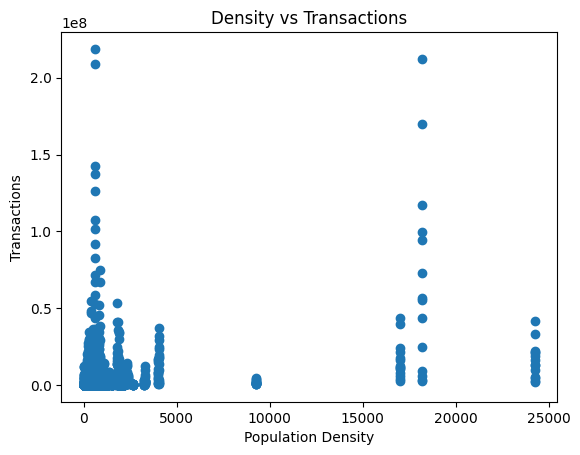

In [98]:
plt.scatter(merged['Density'], merged['Transactions'])

plt.xlabel("Population Density")
plt.ylabel("Transactions")
plt.title("Density vs Transactions")

plt.show()

# 4.3: Average transaction amount per user
1. Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.
2. Identify the top 5 states with the highest average transaction amount per user and the top 5 states with the lowest average transaction amount per user. Display the results.

In [99]:
# Aggregate transaction amount per state
txn_state = df_Statetxn.groupby('State', as_index=False).agg(
    Total_Amount=('Amount (INR)', 'sum')
)

In [100]:
# Aggregate users per state
users_state = df_Statetxn.groupby('State', as_index=False).agg(
    Total_Users=('Registered Users', 'sum')
)

In [101]:
# Merge both
merged = txn_state.merge(users_state, on='State')

In [102]:
# Calculate average amount per user
merged['Avg_Amount_per_User'] = merged['Total_Amount'] / merged['Total_Users']

In [103]:
result = merged[['State', 'Total_Amount', 'Total_Users', 'Avg_Amount_per_User']]

print(result)

                                   State  Total_Amount  Total_Users  \
0              Andaman & Nicobar Islands  3.641818e+09       408396   
1                         Andhra Pradesh  3.187847e+12    158007957   
2                      Arunachal Pradesh  2.225183e+10      1862214   
3                                  Assam  2.814087e+11     26860751   
4                                  Bihar  1.639579e+12    115284760   
5                             Chandigarh  5.371208e+10      3801466   
6                           Chhattisgarh  4.156353e+11     37448388   
7   Dadra & Nagar Haveli and Daman & Diu  1.865878e+10      2701112   
8                                  Delhi  1.649942e+12     95374654   
9                                    Goa  4.427187e+10      4755320   
10                               Gujarat  1.105329e+12    126380032   
11                               Haryana  1.059832e+12     85564119   
12                      Himachal Pradesh  9.786546e+10     13373980   
13    

In [104]:
top_5 = result.sort_values('Avg_Amount_per_User', ascending=False).head(5)

print("Top 5 States (Highest Avg Amount per User):")
print(top_5[['State', 'Avg_Amount_per_User']])

Top 5 States (Highest Avg Amount per User):
             State  Avg_Amount_per_User
31       Telangana         30653.509622
15       Karnataka         21474.282206
1   Andhra Pradesh         20175.233763
28       Rajasthan         17530.768707
8            Delhi         17299.587909


#4.4: Device brand usage ratio
1. Merge the State_DeviceData dataset with the State_Txn and Users dataset.
2. Calculate the ratio of users using each device brand to the total number of registered users in each state. Display the results in a tabular format.
3. Create a bar chart depicting the device brand usage ratio for each state.

In [106]:
df_Devicedata.columns

Index(['State', 'Year', 'Quarter', 'Brand', 'Registered Users', 'Percentage'], dtype='object')

In [113]:
merged = df_Statetxn.merge(df_Devicedata, on='State', how='left')

In [114]:
merged

,State,Year_x,Quarter_x,Transactions,Amount (INR),ATV (INR),Registered Users_x,App Opens,Year_y,Quarter_y,Brand,Registered Users_y,Percentage
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,2018,1,Samsung,1445,0.214392
2,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,2018,1,Vivo,982,0.145697
3,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,2018,1,Oppo,501,0.074332
4,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,2018,1,OnePlus,332,0.049258
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77611,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,2021,2,Lenovo,350841,0.019513
77612,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,2021,2,Asus,297579,0.016551
77613,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,2021,2,Huawei,272965,0.015182
77614,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,2021,2,Apple,201393,0.011201


In [116]:
merged['Brand_User_Ratio'] = merged['Registered Users_x'] / merged['Registered Users_y']


In [117]:
merged = merged.rename(columns={
    'Registered Users_x': 'Brand_Users',
    'Registered Users_y': 'Total_Users'
})

In [118]:
result = merged[['State', 'Brand', 'Brand_Users', 'Total_Users', 'Brand_User_Ratio']]

print(result.head())

                       State    Brand  Brand_Users  Total_Users  \
0  Andaman & Nicobar Islands   Xiaomi         6740         1665   
1  Andaman & Nicobar Islands  Samsung         6740         1445   
2  Andaman & Nicobar Islands     Vivo         6740          982   
3  Andaman & Nicobar Islands     Oppo         6740          501   
4  Andaman & Nicobar Islands  OnePlus         6740          332   

   Brand_User_Ratio  
0          4.048048  
1          4.664360  
2          6.863544  
3         13.453094  
4         20.301205  


In [120]:
agg = filtered.groupby(['State','Brand'], as_index=False).agg(
    Brand_User_Ratio=('Brand_User_Ratio', 'mean')
)

In [121]:
pivot = agg.pivot(index='State', columns='Brand', values='Brand_User_Ratio')

In [123]:
top_brands = (
    agg.groupby('Brand')['Brand_User_Ratio']
    .mean()
    .nlargest(5)
    .index
)

filtered_top = agg[agg['Brand'].isin(top_brands)]

In [124]:
pivot = filtered_top.pivot_table(
    index='State',
    columns='Brand',
    values='Brand_User_Ratio',
    aggfunc='mean'
)

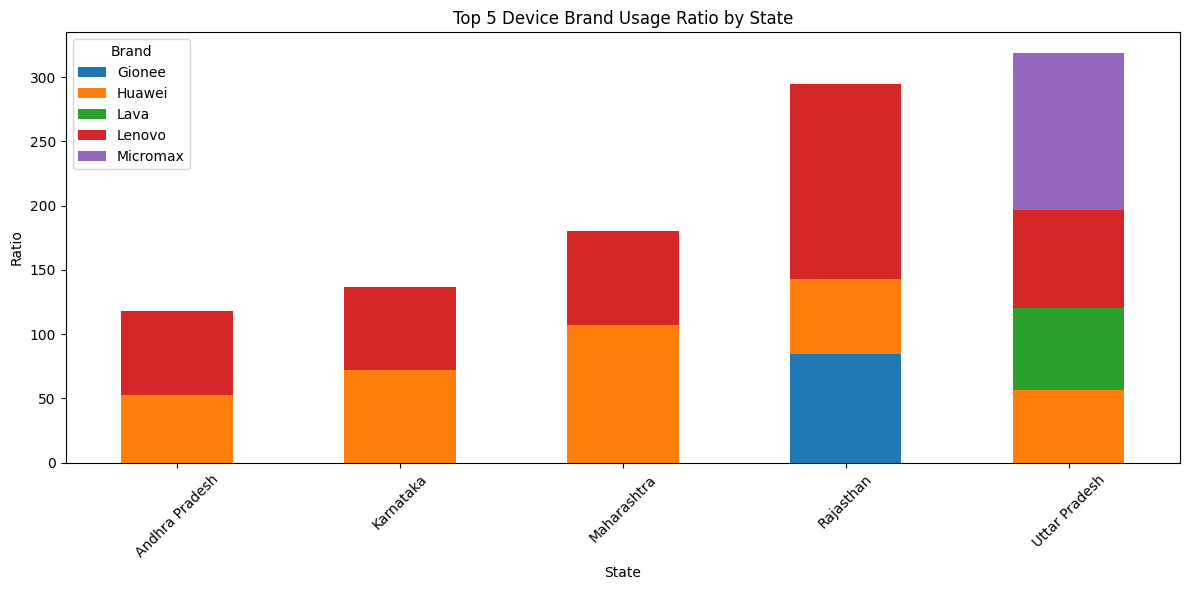

In [125]:
pivot.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Top 5 Device Brand Usage Ratio by State")
plt.ylabel("Ratio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Task 5: Data Visualization
5.1: Plot the total transactions and amount over time for a selected state
1. Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state.
[Hint: you can select any state, maybe your home state or state with max transactions]

In [126]:
state_name = 'Uttar Pradesh'
state_data = df_Statetxn[df_Statetxn['State'] == state_name]

In [127]:
state_data = state_data.sort_values(['Year', 'Quarter'])

In [128]:
state_data['Time'] = state_data['Year'].astype(str) + '-Q' + state_data['Quarter'].astype(str)

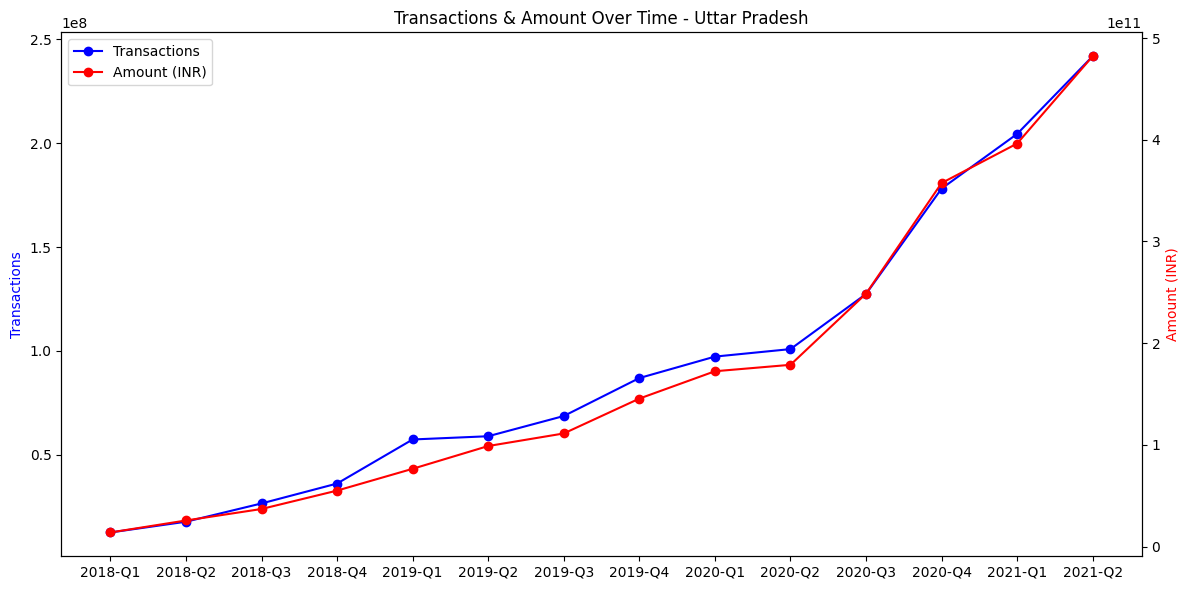

In [131]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Transactions
ax1.plot(state_data['Time'], state_data['Transactions'],
         marker='o', color='blue', label='Transactions')
ax1.set_ylabel("Transactions", color='blue')

# Amount
ax2 = ax1.twinx()
ax2.plot(state_data['Time'], state_data['Amount (INR)'],
         marker='o', color='red', label='Amount (INR)')
ax2.set_ylabel("Amount (INR)", color='red')

# Add legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title(f"Transactions & Amount Over Time - {state_name}")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5.2: Create a pie chart showing the distribution of transaction types for a specific quarter
1. Create a pie chart showing the distribution of different transaction types for a selected state and quarter.

In [132]:
# Selecting State and quarter
state_name = 'Uttar Pradesh'
year = 2020
quarter = 2

filtered = df_Statetxnsplit[
    (df_Statetxnsplit['State'] == state_name) &
    (df_Statetxnsplit['Year'] == year) &
    (df_Statetxnsplit['Quarter'] == quarter)
]

In [133]:
# Aggregate by transaction type
txn_dist = filtered.groupby('Transaction Type')['Transactions'].sum()

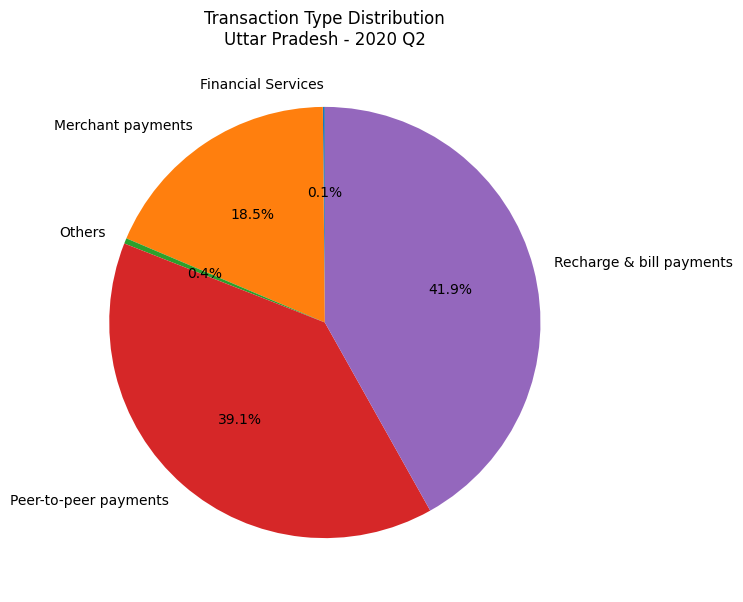

In [134]:
plt.figure(figsize=(7,7))

plt.pie(txn_dist, labels=txn_dist.index, autopct='%1.1f%%', startangle=90)

plt.title(f"Transaction Type Distribution\n{state_name} - {year} Q{quarter}")

plt.show()

#5.3: Visualize the population density of districts in a selected state
1. Create a bar plot showing the population density of districts in a selected state.

In [135]:
# Select State
state_name = 'Uttar Pradesh'   # you can change this

state_data = df_Demographics[df_Demographics['State'] == state_name]

In [136]:
# Sorting
state_data = state_data.sort_values('Density', ascending=False)

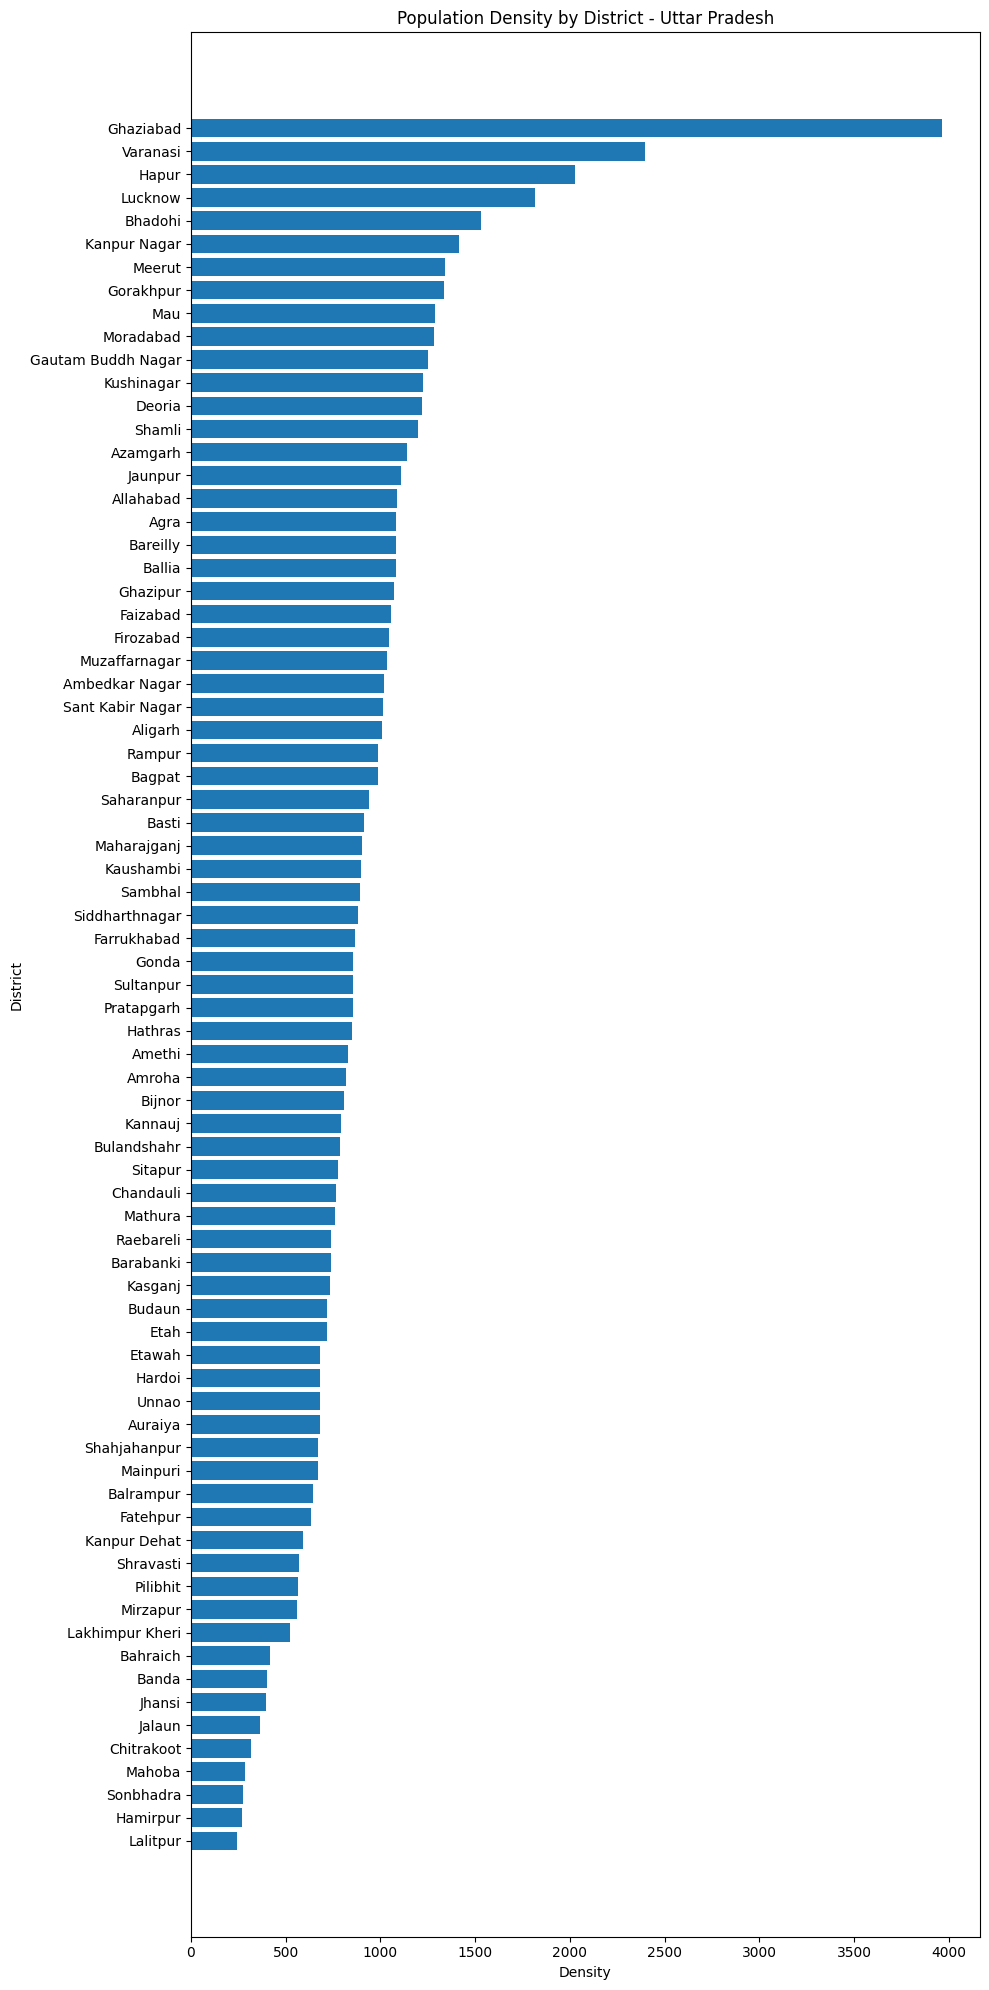

In [138]:

plt.figure(figsize=(10, 20))

plt.barh(state_data['District'], state_data['Density'])

plt.title(f"Population Density by District - {state_name}")
plt.xlabel("Density")
plt.ylabel("District")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#Task 6: Insights and Conclusions [Advanced Section]
6.1: Identify any trends or patterns in the transaction data
1. Analyze the transaction data to identify any noticeable trends or patterns. Summarize your findings.


# Strong upward trend

- There is a consistent upward trend in both transactions and transaction amount, indicating continuous growth in digital payment adoption

# Major acceleration after 2020

- A sharp increase is observed after 2020, suggesting accelerated digital adoption during and after the COVID period.

# Amount and transactions move together

- Transaction volume and transaction value are highly correlated, showing that increased usage directly leads to higher monetary flow.




*From the time-series analysis of Uttar Pradesh, I observed a consistent upward trend in both transaction volume and transaction amount from 2018 to 2021. There is a noticeable acceleration after 2020, indicating increased digital adoption during the pandemic. Both metrics move closely together, showing strong correlation between usage and value. Additionally, spikes in certain quarters suggest seasonal effects, and the continued growth indicates that the market has not yet reached saturation*

# 6.2: Correlate demographic data with transaction data
1. Find correlations between demographic data (e.g., population density) and transaction data

In [143]:
print(df_district.columns)
print(df_Demographics.columns)

Index(['State', 'Year', 'Quarter', 'District', 'Code', 'Transactions',
       'Amount (INR)', 'ATV (INR)', 'Registered Users', 'App Opens'],
      dtype='object')
Index(['State', 'District', 'Headquarters', 'Population', 'Area (sq km)',
       'Density', 'Code', 'Alternate Name'],
      dtype='object')


In [144]:
merged = df_district.merge(
    df_Demographics[['State', 'District', 'Density']],
    on=['State', 'District'],
    how='left'
)

In [145]:
# Remove missing values or cols

merged = merged.dropna(subset=['Density', 'Transactions'])

In [146]:
correlation = merged['Density'].corr(merged['Transactions'])

print("Correlation between Population Density and Transactions:", correlation)

Correlation between Population Density and Transactions: 0.30770410875592863


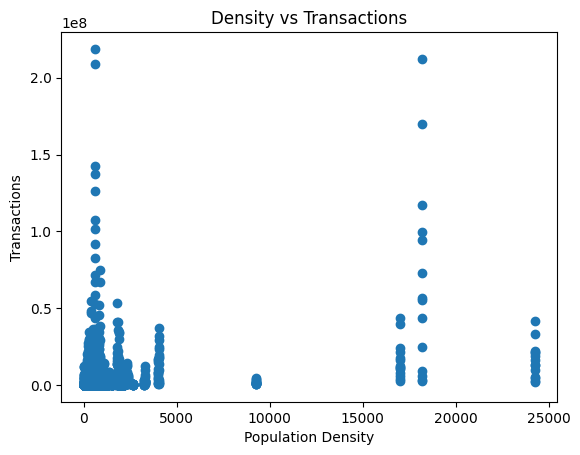

In [147]:
plt.scatter(merged['Density'], merged['Transactions'])

plt.xlabel("Population Density")
plt.ylabel("Transactions")
plt.title("Density vs Transactions")

plt.show()

# Insight 1
 - There is a weak to moderate positive correlation between population density and transaction volume, indicating that higher-density districts tend to have more digital transactions.


 # Insight 2
  - Population density alone is not a strong predictor of transaction activity, suggesting that other factors significantly influence digital payments.


*The correlation analysis between population density and transaction volume shows a weak to moderate positive relationship, indicating that densely populated districts tend to have higher transaction activity. However, since the correlation is not strong, population density alone does not fully explain transaction behavior. Other factors such as digital infrastructure, smartphone penetration, and economic conditions also significantly influence digital payment adoption. This suggests that while urban areas drive transaction growth, there is still potential for expansion in less densely populated regions.*

#6.3: Summarize findings and insights
1. Summarize the key findings and insights from your analysis. Provide actionable recommendations based on the data.

In [148]:
print("""
KEY FINDINGS:

1. There is a strong upward trend in digital transactions over time, showing rapid growth in adoption.

2. A significant increase in transactions is observed after 2020, likely due to increased reliance on digital payments during the COVID-19 period.

3. Transaction amounts are increasing faster than transaction counts, indicating higher-value transactions over time.

4. Urban and high-population states contribute the most to transaction volume, highlighting regional concentration.

5. The correlation between population density and transaction volume is weak to moderate, suggesting that density alone does not fully explain digital adoption.

6. Device analysis shows that a few smartphone brands dominate usage, indicating the role of affordable smartphones in driving digital payments.

7. Transaction types such as peer-to-peer and merchant payments dominate, reflecting everyday usage patterns.
""")


KEY FINDINGS:

1. There is a strong upward trend in digital transactions over time, showing rapid growth in adoption.

2. A significant increase in transactions is observed after 2020, likely due to increased reliance on digital payments during the COVID-19 period.

3. Transaction amounts are increasing faster than transaction counts, indicating higher-value transactions over time.

4. Urban and high-population states contribute the most to transaction volume, highlighting regional concentration.

5. The correlation between population density and transaction volume is weak to moderate, suggesting that density alone does not fully explain digital adoption.

6. Device analysis shows that a few smartphone brands dominate usage, indicating the role of affordable smartphones in driving digital payments.

7. Transaction types such as peer-to-peer and merchant payments dominate, reflecting everyday usage patterns.



In [149]:
print("""

1. Focus on improving digital infrastructure in low-density and rural areas to increase adoption.

2. Promote digital literacy programs to encourage usage among less tech-savvy populations.

3. Collaborate with smartphone manufacturers to further expand access to affordable devices.

4. Encourage small businesses to adopt digital payment systems to increase merchant transactions.

5. Leverage festive seasons and events to drive higher transaction volumes through targeted campaigns.

6. Improve internet connectivity and payment reliability in underserved regions.

7. Develop incentives such as cashback or rewards to increase user engagement and transaction frequency.
""")



1. Focus on improving digital infrastructure in low-density and rural areas to increase adoption.

2. Promote digital literacy programs to encourage usage among less tech-savvy populations.

3. Collaborate with smartphone manufacturers to further expand access to affordable devices.

4. Encourage small businesses to adopt digital payment systems to increase merchant transactions.

5. Leverage festive seasons and events to drive higher transaction volumes through targeted campaigns.

6. Improve internet connectivity and payment reliability in underserved regions.

7. Develop incentives such as cashback or rewards to increase user engagement and transaction frequency.

